In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Explore Churn Dataset**

In [8]:
churn = pd.read_csv("/Users/estelle90/Downloads/ChurnAnalysisProject/archive 2/data.csv")
churn.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,customerID
0,No,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,No,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2
2,Yes,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3
3,No,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,4
4,Yes,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,5


In [9]:
churn.tail()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,customerID
2995,No,Female,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),25.25,25.25,2996
2996,No,Female,0,No,No,18,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,Yes,Mailed check,60.60,1156.35,2997
2997,Yes,Male,1,Yes,No,69,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.95,6143.15,2998
2998,No,Male,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.75,144.80,2999
2999,No,Male,0,Yes,Yes,19,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.60,414.95,3000


In [10]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.158333,32.527333,65.347400,2299.722650,1500.500000
std,0.365114,24.637768,30.137053,2273.769694,866.169729
min,0.000000,0.000000,18.400000,18.800000,1.000000
25%,0.000000,9.000000,35.787500,415.325000,750.750000
50%,0.000000,29.000000,70.900000,1402.900000,1500.500000
75%,0.000000,56.000000,90.262500,3865.487500,2250.250000
max,1.000000,72.000000,118.650000,8564.750000,3000.000000


Not all columns start with a Capital letter, for unity when indexing, I will capitalise the first letter of each variable

In [11]:
churn.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'customerID'],
      dtype='object')

I have decided to drop the following columns 

In [13]:
churn.dtypes

Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
customerID            int64
dtype: object

In [14]:
churn.shape

(3000, 21)

In [15]:
churn.isnull().sum()

Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
customerID          0
dtype: int64

In [16]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             3000 non-null   object 
 1   gender            3000 non-null   object 
 2   SeniorCitizen     3000 non-null   int64  
 3   Partner           3000 non-null   object 
 4   Dependents        3000 non-null   object 
 5   tenure            3000 non-null   int64  
 6   PhoneService      3000 non-null   object 
 7   MultipleLines     3000 non-null   object 
 8   InternetService   3000 non-null   object 
 9   OnlineSecurity    3000 non-null   object 
 10  OnlineBackup      3000 non-null   object 
 11  DeviceProtection  3000 non-null   object 
 12  TechSupport       3000 non-null   object 
 13  StreamingTV       3000 non-null   object 
 14  StreamingMovies   3000 non-null   object 
 15  Contract          3000 non-null   object 
 16  PaperlessBilling  3000 non-null   object 


In [18]:
churn.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,3000.0,0.158333,0.365114,0.0,0.0000,0.0,0.0000,1.00
tenure,3000.0,32.527333,24.637768,0.0,9.0000,29.0,56.0000,72.00
MonthlyCharges,3000.0,65.347400,30.137053,18.4,35.7875,70.9,90.2625,118.65
TotalCharges,3000.0,2299.722650,2273.769694,18.8,415.3250,1402.9,3865.4875,8564.75
customerID,3000.0,1500.500000,866.169729,1.0,750.7500,1500.5,2250.2500,3000.00


In [35]:
print(churn['Churn'].value_counts().to_string())

Churn
0    2220
1     780


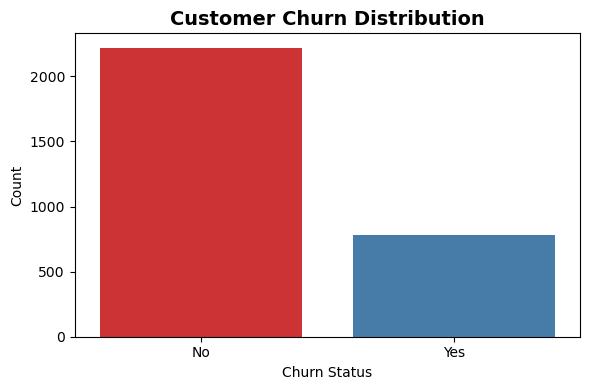

Churn Rate:
Churn
No     74.0
Yes    26.0
Name: proportion, dtype: float64


In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=churn, palette="Set1")
plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Count")
plt.xlabel("Churn Status")
plt.tight_layout()
plt.show()

# Clean percentage output
print("Churn Rate:")
print(churn["Churn"].value_counts(normalize=True).round(3) * 100)

- Before dropping any columns I wanted to check for correlations to make sure I am not removing key varibales

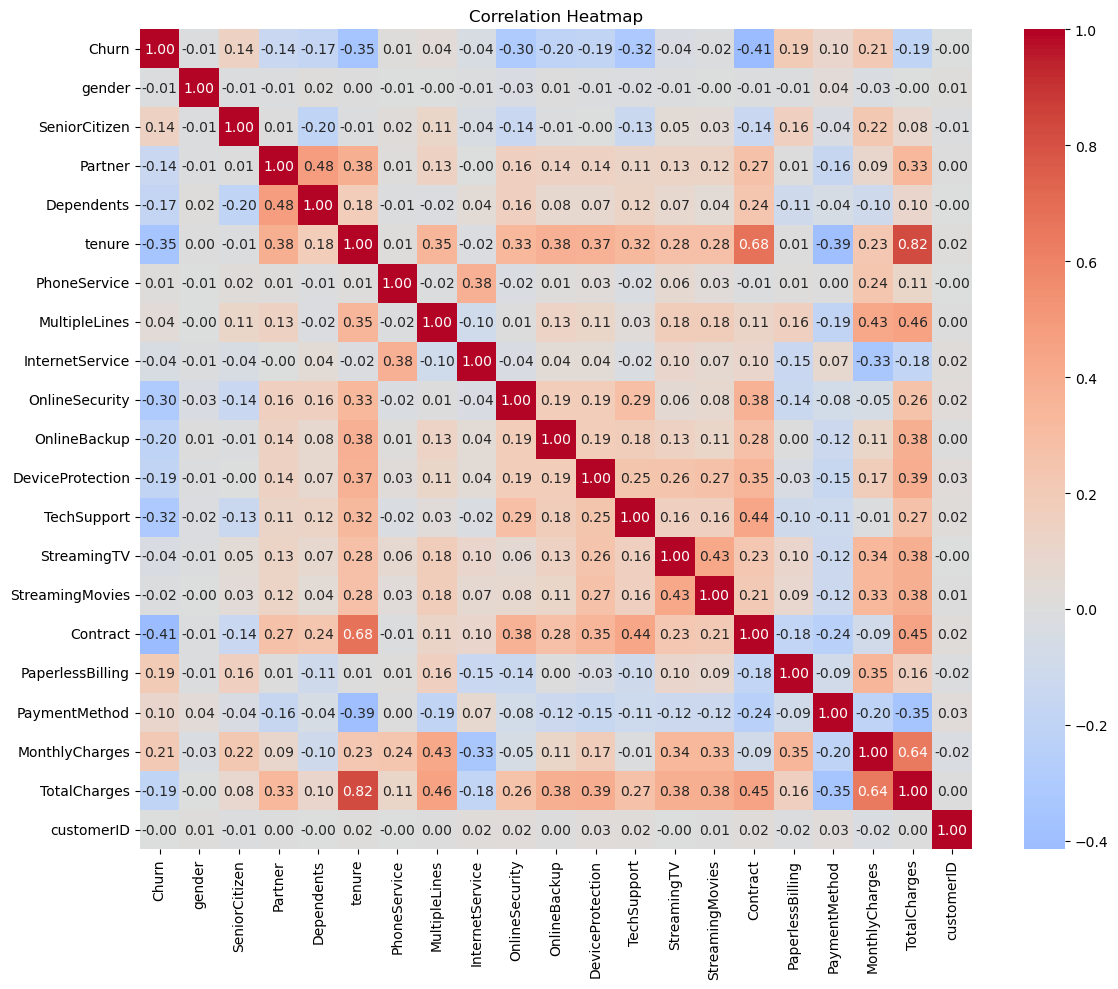

In [34]:
cat_cols = churn.select_dtypes(include=['object'])

for col in cat_cols:
    churn[col] = churn[col].astype('category').cat.codes

plt.figure(figsize=(12, 10))
corr = churn.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


****Heatmap Correlation Observation****

*Correation between factors and Churn*

- Contract type suggest a moderate to strong correlation **0.41**
- Tech Support moderate correaltion **0.32**
- Online sercurity moderate correlation??? **0.30** *to include or not relevant*
- Tenure moderate correaltion **0.35**

***When looking at the heatmap I noticed that Tenure had a lot of strong correlations***

My initail focus and target variable is 'Churn' however, it would be intersting to see what factors can go hand in hand to promote both longevity as well as loyalty.


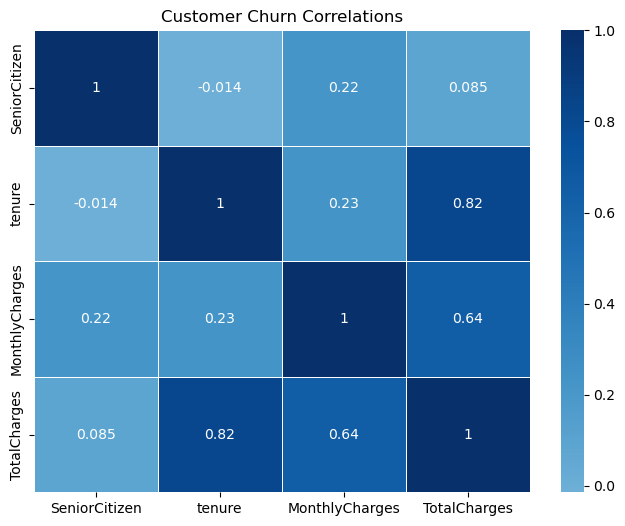

In [44]:
plt.figure(figsize=(8, 6))

corr = churn_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    center=0,
    linewidths=0.5  # adds thin white lines between cells
)

plt.title('Customer Churn Correlations')  
plt.show()